<a href="https://colab.research.google.com/github/thaenraj/Competitive-Programming/blob/master/Thaenraj_Packiamani_Class_3_VAE_MNIST_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Variational Autoencoder**

The code defines two functions: `sample_batch` and `display`.

1. `sample_batch(dataset)`:
   - This function takes a `dataset` as input.
   - It uses the `take(1)` method to retrieve a single batch from the dataset and then calls `get_single_element()` to extract the actual batch data.
   - If the batch is a tuple, it assumes that the first element of the tuple represents the batch data and assigns it to `batch`.
   - Finally, it returns the batch data as a NumPy array using `batch.numpy()`.

2. `display(images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None)`:
   - This function is used to display a grid of images.
   - It takes the following parameters:
     - `images`: An array or tensor containing the images to be displayed.
     - `n`: The number of images to display (default is 10).
     - `size`: The size of the figure in inches (default is (20, 3)).
     - `cmap`: The colormap to use for displaying the images (default is "gray_r" for grayscale images).
     - `as_type`: The data type to cast the images to (default is "float32").
     - `save_to`: A file path to save the displayed figure (optional).
   - The function first normalizes the pixel values of the images:
     - If the maximum value is greater than 1.0, it divides the images by 255.0 to scale them to the range [0, 1].
     - If the minimum value is less than 0.0, it adds 1.0 to the images and then divides by 2.0 to scale them to the range [0, 1].
   - It creates a new figure with the specified size using `plt.figure(figsize=size)`.
   - It iterates over the first `n` images in the `images` array.
   - For each image, it creates a subplot using `plt.subplot(1, n, i + 1)` to arrange the images in a single row.
   - It displays the image using `plt.imshow()`, passing the image data, colormap, and data type.
   - It removes the axis labels and ticks using `plt.axis("off")`.
   - If `save_to` is provided, it saves the figure to the specified file path using `plt.savefig(save_to)` and prints a message indicating the file path.
   - Finally, it displays the figure using `plt.show()`.

These functions provide a convenient way to sample a batch of data from a dataset and display a grid of images with optional normalization and saving capabilities.

In [2]:
import matplotlib.pyplot as plt
import os


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    datasets,
    callbacks,
    losses,
    optimizers,
    metrics,
)

from scipy.stats import norm

In [4]:
IMAGE_SIZE = 32
BATCH_SIZE = 100
VALIDATION_SPLIT = 0.2
EMBEDDING_DIM = 2
EPOCHS = 5
BETA = 500

In [5]:
# Load the data
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = imgs.astype("float32") / 255.0
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=0.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

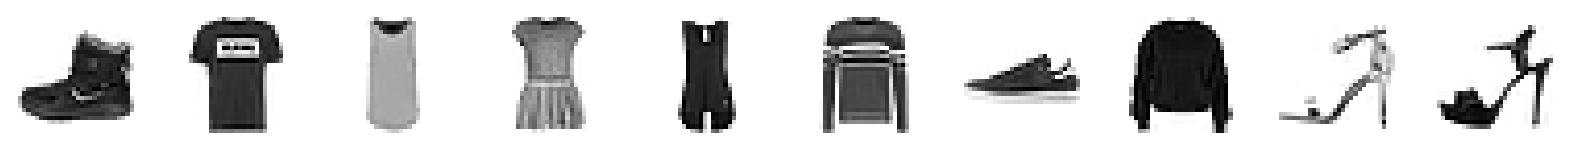

In [7]:
# Show some items of clothing from the training set
display(x_train)

In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [9]:
# Encoder
encoder_input = layers.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 1), name="encoder_input"
)
x = layers.Conv2D(32, (3, 3), strides=2, activation="relu", padding="same")(
    encoder_input
)
x = layers.Conv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, (3, 3), strides=2, activation="relu", padding="same")(x)
shape_before_flattening = K.int_shape(x)[1:]  # the decoder will need this!

x = layers.Flatten()(x)
z_mean = layers.Dense(EMBEDDING_DIM, name="z_mean")(x)
z_log_var = layers.Dense(EMBEDDING_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 4, 4, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │      4,098 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │      4,098 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,868 (394.02 KB)

 Trainable params: 100,868 (394.02 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
decoder_input = layers.Input(shape=(EMBEDDING_DIM,), name="decoder_input")
x = layers.Dense(int(np.prod(shape_before_flattening)))(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(
    128, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    64, (3, 3), strides=2, activation="relu", padding="same"
)(x)
x = layers.Conv2DTranspose(
    32, (3, 3), strides=2, activation="relu", padding="same"
)(x)
decoder_output = layers.Conv2D(
    1,
    (3, 3),
    strides=1,
    activation="sigmoid",
    padding="same",
    name="decoder_output",
)(x)

decoder = models.Model(decoder_input, decoder_output)
decoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,273 (962.00 KB)

 Trainable params: 246,273 (962.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({
            "encoder_config": self.encoder.get_config(),
            "decoder_config": self.decoder.get_config(),
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Reconstruct encoder and decoder from their configurations
        # Note: This assumes 'models.model_from_config' can reconstruct
        # the encoder and decoder. If they are custom classes, you might
        # need to register them with Keras or pass custom_objects.
        encoder = models.model_from_config(config.pop("encoder_config"))
        decoder = models.model_from_config(config.pop("decoder_config"))
        return cls(encoder=encoder, decoder=decoder, **config)

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        """Call the model on a particular input."""
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, reconstruction

    def train_step(self, data):
        """Step run during training."""
        with tf.GradientTape() as tape:
            z_mean, z_log_var, reconstruction = self(data)
            reconstruction_loss = tf.reduce_mean(
                BETA
                * losses.binary_crossentropy(
                    data, reconstruction, axis=(1, 2, 3)
                )
            )
            kl_loss = tf.reduce_mean(
                tf.reduce_sum(
                    -0.5
                    * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                    axis=1,
                )
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        """Step run during validation."""
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, reconstruction = self(data)
        reconstruction_loss = tf.reduce_mean(
            BETA
            * losses.binary_crossentropy(data, reconstruction, axis=(1, 2, 3))
        )
        kl_loss = tf.reduce_mean(
            tf.reduce_sum(
                -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                axis=1,
            )
        )
        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [13]:
# Create a variational autoencoder
vae = VAE(encoder, decoder)

In [14]:
# Compile the variational autoencoder
optimizer = optimizers.Adam(learning_rate=0.0005)
vae.compile(optimizer=optimizer)

In [15]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/model.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

In [16]:
vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test, x_test),
    callbacks=[model_checkpoint_callback, tensorboard_callback],
)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - kl_loss: 4.2717 - reconstruction_loss: 157.8148 - total_loss: 162.0866 - val_kl_loss: 4.7493 - val_loss: 143.1442 - val_reconstruction_loss: 138.3949
Epoch 2/5
  1/600 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - kl_loss: 4.7647 - reconstruction_loss: 128.5852 - total_loss: 133.3499

/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 4.8528 - reconstruction_loss: 131.4390 - total_loss: 136.2917 - val_kl_loss: 4.8734 - val_loss: 139.4754 - val_reconstruction_loss: 134.6020
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - kl_loss: 4.9430 - reconstruction_loss: 129.5615 - total_loss: 134.5045 - val_kl_loss: 5.0230 - val_loss: 138.2472 - val_reconstruction_loss: 133.2242
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 5.0121 - reconstruction_loss: 128.6616 - total_loss: 133.6736 - val_kl_loss: 4.9973 - val_loss: 137.1879 - val_reconstruction_loss: 132.1906
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - kl_loss: 5.0672 - reconstruction_loss: 128.0185 - total_loss: 133.0855 - val_kl_loss: 5.1579 - val_loss: 137.2741 - val_reconstruction_loss: 132.1162


In [17]:
# Save the final models
# vae.save("./models/vae")
# encoder.save("./models/encoder")
# decoder.save("./models/decoder")

# Create the models directory if it doesn't exist
os.makedirs("./models", exist_ok=True)

# Save the final models
vae.save("./models/vae.keras")
encoder.save("./models/encoder.keras")
decoder.save("./models/decoder.keras")

In [18]:
# Select a subset of the test set
n_to_predict = 5000
example_images = x_test[:n_to_predict]
example_labels = y_test[:n_to_predict]

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Example real clothing items


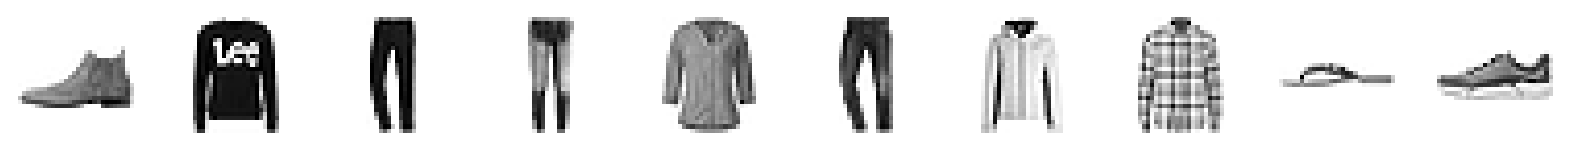

Reconstructions


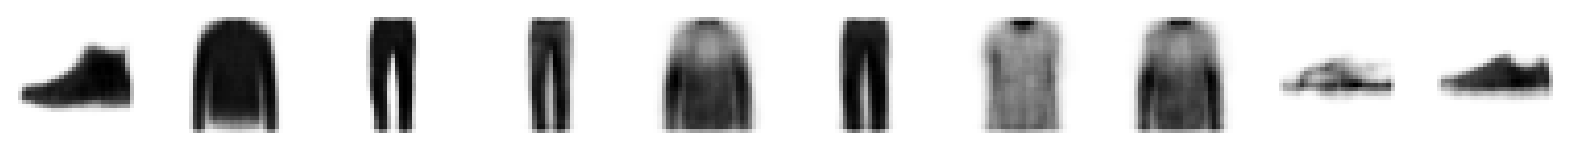

In [19]:
# Create autoencoder predictions and display
z_mean, z_log_var, reconstructions = vae.predict(example_images)
print("Example real clothing items")
display(example_images)
print("Reconstructions")
display(reconstructions)

In [38]:
# Encode the example images
z_mean, z_var, z = encoder.predict(example_images)
print (z_mean, z_var)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[-1.2963704   1.0399153 ]
 [ 1.2498649   0.76842964]
 [ 1.128979   -2.4887273 ]
 ...
 [ 0.48907334  2.2344975 ]
 [ 0.7278542  -0.9541746 ]
 [-2.1015325  -0.33374706]] [[-5.261862  -3.8916314]
 [-4.949706  -6.123811 ]
 [-3.7838464 -3.5895815]
 ...
 [-5.6875834 -4.4079213]
 [-4.303005  -4.884876 ]
 [-3.895383  -4.0953794]]


In [21]:
# Some examples of the embeddings
print(z[:10])

[[-1.2091411   0.9249101 ]
 [ 1.222031    0.7674006 ]
 [ 1.2047713  -2.1615064 ]
 [ 0.16018575 -1.938587  ]
 [ 0.42515755  0.3660491 ]
 [ 0.9233546  -1.6833273 ]
 [ 0.12778862 -0.42860243]
 [ 0.3256845   0.01403144]
 [-1.746061   -1.1306313 ]
 [-1.9496818  -0.26282567]]


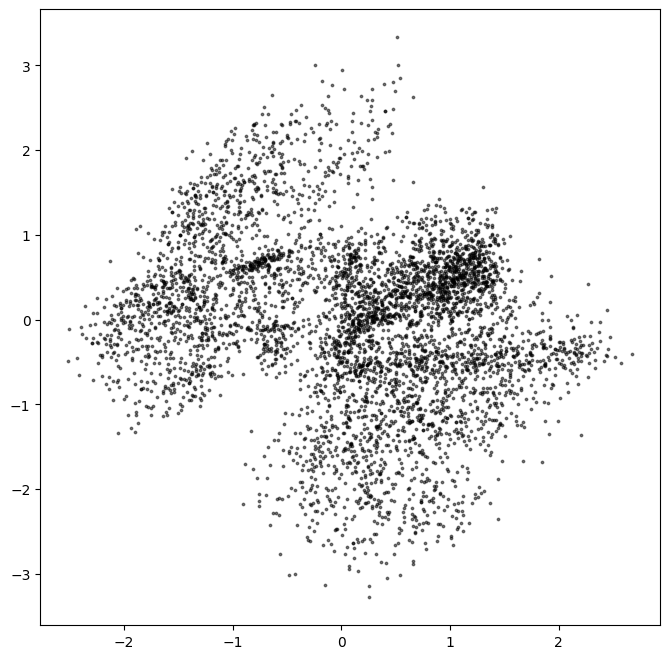

In [22]:
# Show the encoded points in 2D space
figsize = 8

plt.figure(figsize=(figsize, figsize))
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=3)
plt.show()

In [39]:
# Sample some points in the latent space, from the standard normal distribution
grid_width, grid_height = (6, 3)
# hard coded may break when we change the embedding dim
#z_sample = np.random.normal(size=(grid_width * grid_height, 2))
z_sample = np.random.normal(size=(grid_width * grid_height, EMBEDDING_DIM))


In [30]:
# Decode the sampled points
reconstructions = decoder.predict(z_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [36]:
# Convert original embeddings and sampled embeddings to p-values
p = norm.cdf(z)
p_sample = norm.cdf(z_sample)
print ('the value of p_values and its dim are ', p)

the value of p_values and its dim are  [[0.11330431 0.82249367]
 [0.88915205 0.77857832]
 [0.8858542  0.01532812]
 ...
 [0.6664128  0.98887933]
 [0.7398946  0.18361751]
 [0.01908144 0.31555219]]


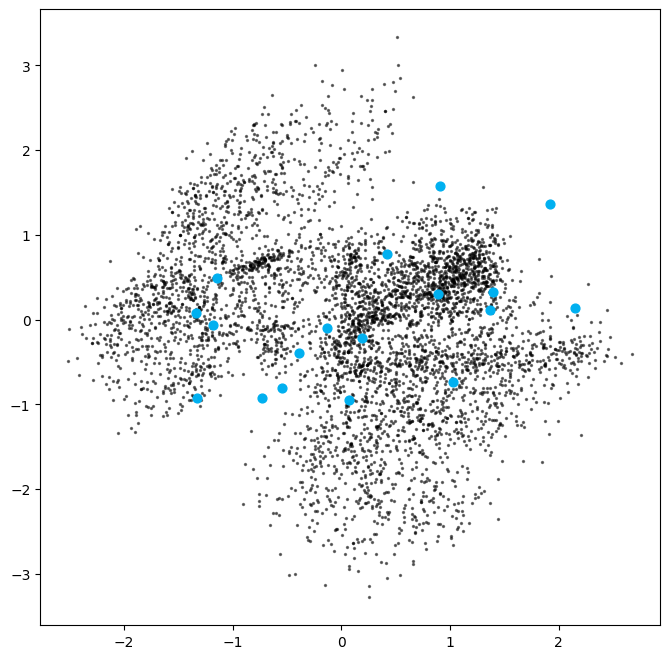

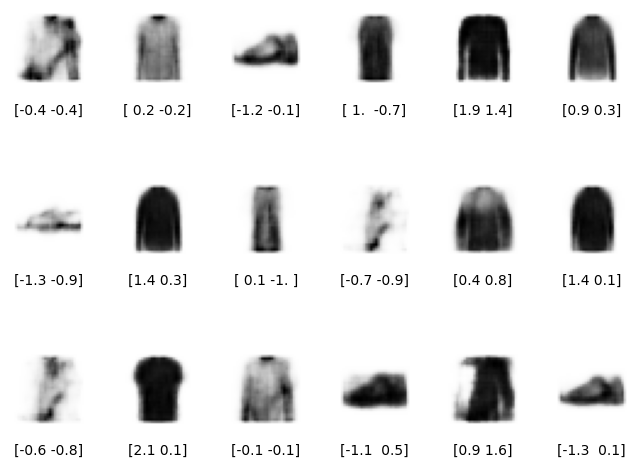

In [27]:
# Draw a plot of...
figsize = 8
plt.figure(figsize=(figsize, figsize))

# ... the original embeddings ...
plt.scatter(z[:, 0], z[:, 1], c="black", alpha=0.5, s=2)

# ... and the newly generated points in the latent space
plt.scatter(z_sample[:, 0], z_sample[:, 1], c="#00B0F0", alpha=1, s=40)
plt.show()

# Add underneath a grid of the decoded images
fig = plt.figure(figsize=(figsize, grid_height * 2))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.text(
        0.5,
        -0.35,
        str(np.round(z_sample[i, :], 1)),
        fontsize=10,
        ha="center",
        transform=ax.transAxes,
    )
    ax.imshow(reconstructions[i, :, :], cmap="Greys")

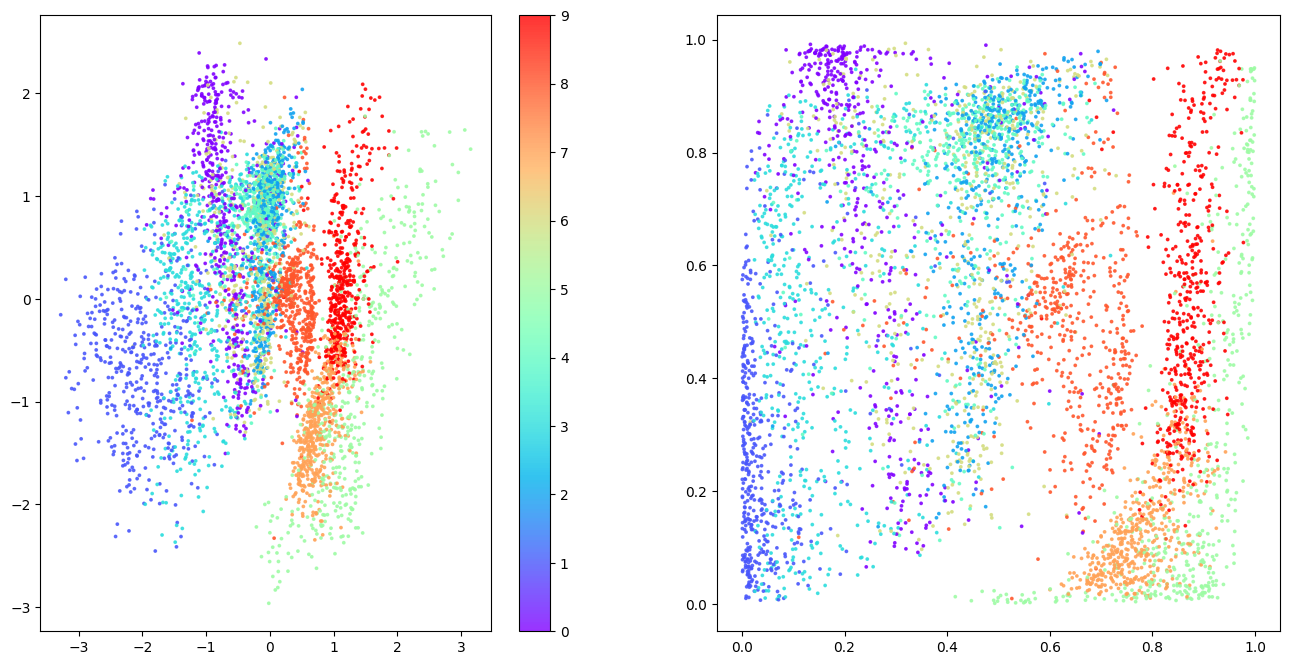

In [ ]:
# Colour the embeddings by their label (clothing type - see table)
figsize = 8
fig = plt.figure(figsize=(figsize * 2, figsize))
ax = fig.add_subplot(1, 2, 1)
plot_1 = ax.scatter(
    z[:, 0], z[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.colorbar(plot_1)
ax = fig.add_subplot(1, 2, 2)
plot_2 = ax.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=3
)
plt.show()

ID	Clothing Label
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step


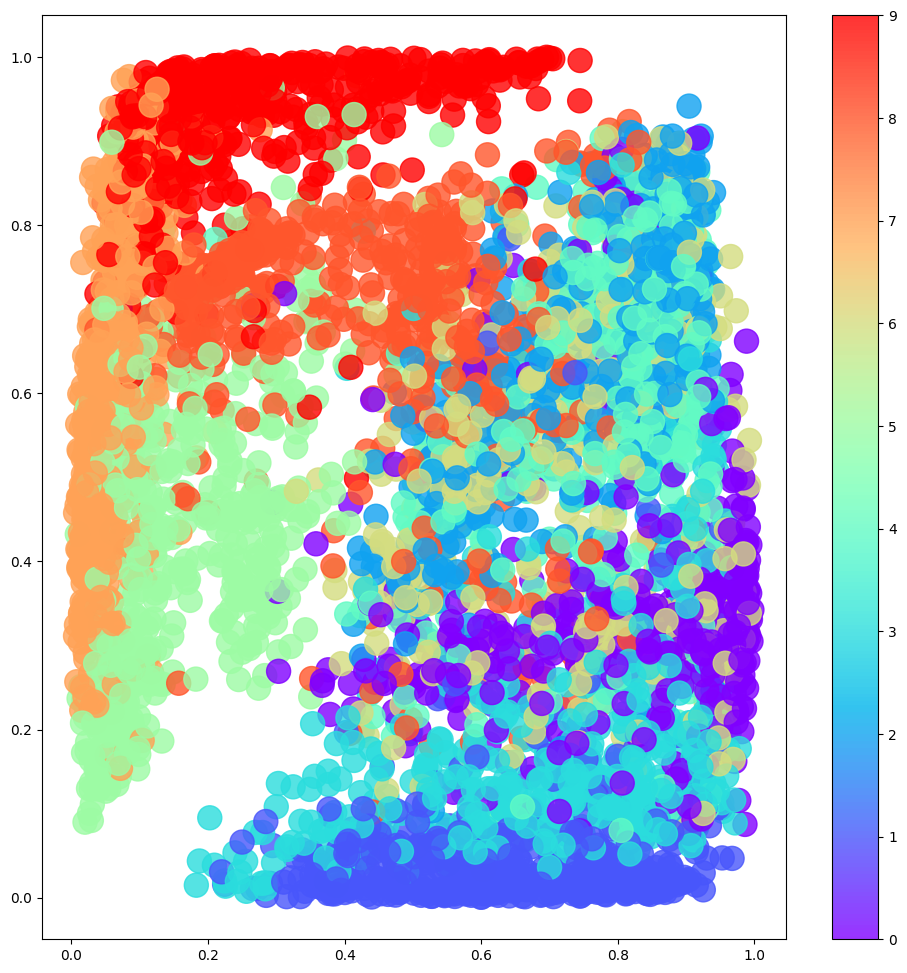

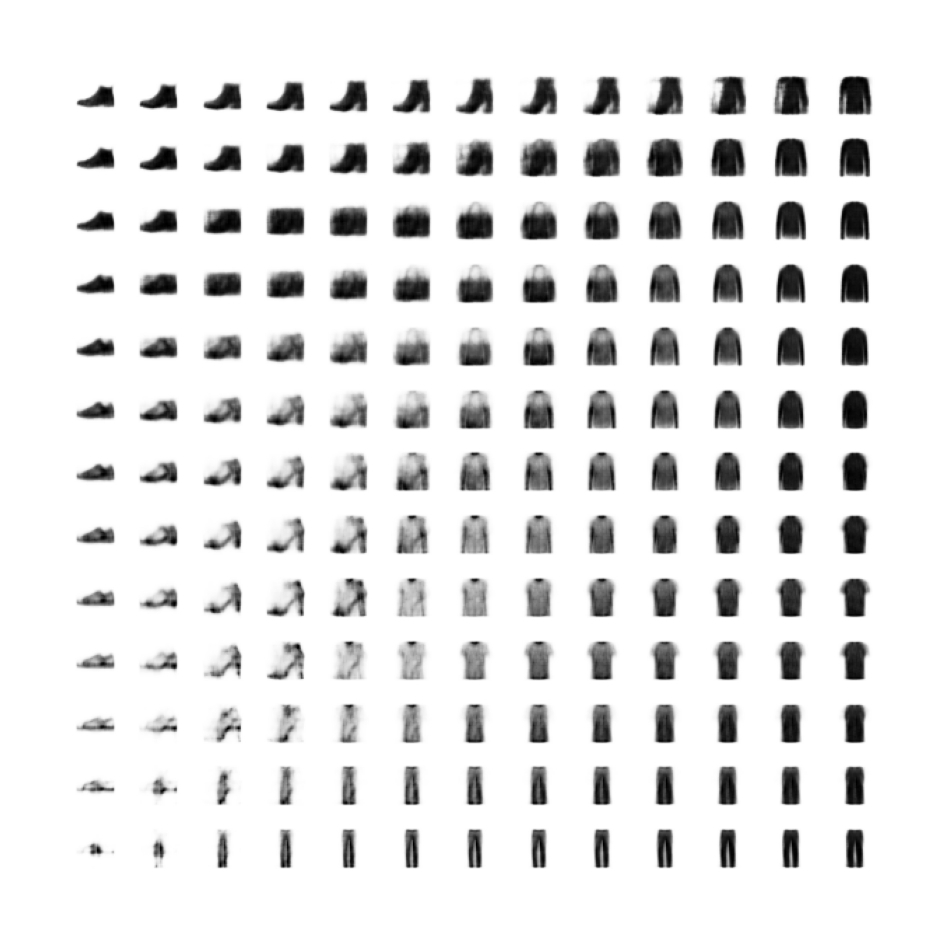

In [28]:
# Colour the embeddings by their label (clothing type - see table)
figsize = 12
grid_size = 15
plt.figure(figsize=(figsize, figsize))
plt.scatter(
    p[:, 0], p[:, 1], cmap="rainbow", c=example_labels, alpha=0.8, s=300
)
plt.colorbar()

x = norm.ppf(np.linspace(0, 1, grid_size))
y = norm.ppf(np.linspace(1, 0, grid_size))
xv, yv = np.meshgrid(x, y)
xv = xv.flatten()
yv = yv.flatten()
grid = np.array(list(zip(xv, yv)))

reconstructions = decoder.predict(grid)
# plt.scatter(grid[:, 0], grid[:, 1], c="black", alpha=1, s=10)
plt.show()

fig = plt.figure(figsize=(figsize, figsize))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(grid_size**2):
    ax = fig.add_subplot(grid_size, grid_size, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i, :, :], cmap="Greys")

In [40]:
# change the embedding_dim, epochs, beta values and observe both the construnction loss and KL loss
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
# build_vae() function creates new layers. New layers start with random, untrained weights; they know nothing yet.
# basically both the encoder and decoder layers are built in this funtion.
# the function VAE(enc, dec) and model.compile() wrap them and attach a new optimizer.

def build_vae(embedding_dim):
    # Encoder: same layers as the "# Encoder" cell
    enc_in = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
    x = layers.Conv2D(32, (3, 3), strides=2, activation="relu", padding="same")(enc_in)
    x = layers.Conv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, (3, 3), strides=2, activation="relu", padding="same")(x)
    shape = K.int_shape(x)[1:]
    x = layers.Flatten()(x)
    z_mean = layers.Dense(embedding_dim, name="z_mean")(x)
    z_log_var = layers.Dense(embedding_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    enc = models.Model(enc_in, [z_mean, z_log_var, z], name="encoder")

    # Decoder: same layers as the decoder cell
    dec_in = layers.Input(shape=(embedding_dim,))
    x = layers.Dense(int(np.prod(shape)))(dec_in)
    x = layers.Reshape(shape)(x)
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
    dec_out = layers.Conv2D(1, (3, 3), strides=1, activation="sigmoid", padding="same")(x)
    dec = models.Model(dec_in, dec_out, name="decoder")
    return enc, dec

# each experiment builds a new model and trains it from the scratch .
# model.fit() trains this new model on the data, using that experiemnt row's  Embedding_dim and Beta values .
# more_epochs vs baseline	EPOCHS 5 to  20 ; and check the effect of training longer
# dim16 vs baseline	EMBEDDING_DIM 2 to 16; and check the Effect of latent size
# dim16_beta50 vs dim16	BETA 500 to  50; and check the Effect of the reconstruction weight
#


def run_experiment(name, embedding_dim, beta, epochs, seed=42):
    global BETA
    BETA = beta                          # the VAE class reads this global
    tf.keras.utils.set_random_seed(seed) # same starting weights for every run

    enc, dec = build_vae(embedding_dim)
    model = VAE(enc, dec)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0005))
    print(f"\n=== {name}: EMBEDDING_DIM={embedding_dim}, BETA={beta}, EPOCHS={epochs} ===")
    h = model.fit(x_train, epochs=epochs, batch_size=BATCH_SIZE, shuffle=True,
                  validation_data=(x_test, x_test), verbose=2)
    last = {k: v[-1] for k, v in h.history.items()}

    # Metrics that do NOT depend on BETA, so every run is comparable
    z_test = enc.predict(x_test, verbose=0)[0]            # z_mean
    recon = dec.predict(z_test, verbose=0)
    pixel_mse = float(np.mean((x_test - recon) ** 2))

    z_train = enc.predict(x_train[:10000], verbose=0)[0]
    knn = KNeighborsClassifier(n_neighbors=5).fit(z_train, y_train[:10000])
    knn_acc = float(knn.score(z_test, y_test))

    row = {
        "run": name, "dim": embedding_dim, "beta": beta, "epochs": epochs,
        "recon_loss": round(last["reconstruction_loss"], 2),
        "recon_per_beta": round(last["reconstruction_loss"] / beta, 4),
        "kl_loss": round(last["kl_loss"], 2),
        "val_total": round(last["val_loss"], 2),
        "pixel_mse": round(pixel_mse, 4),
        "knn_acc": round(knn_acc, 3),
    }
    return row, enc, dec

In [41]:
# set the experiments with different values for  baseline and other experiments
experiments = [
    # name,          dim, beta, epochs
    ("baseline",      2,   500,  5),
    ("more_epochs",   2,   500,  20),
    ("dim16",         16,  500,  5),
    ("beta50",        2,   50,   5),
    ("beta2000",      2,   2000, 5),
]

results, trained = [], {}
# for each experiment values call the run_experiment with the parameters values embedding_dim, beta and epochs and keep its results
for name, dim, beta, ep in experiments:
    row, enc, dec = run_experiment(name, dim, beta, ep)
    results.append(row)
    trained[name] = (enc, dec, dim)

results_df = pd.DataFrame(results).set_index("run")
results_df


=== baseline: EMBEDDING_DIM=2, BETA=500, EPOCHS=5 ===
Epoch 1/5
600/600 - 12s - 19ms/step - kl_loss: 4.3723 - reconstruction_loss: 157.1448 - total_loss: 161.5172 - val_kl_loss: 4.8301 - val_loss: 141.6633 - val_reconstruction_loss: 136.8332
Epoch 2/5
600/600 - 5s - 9ms/step - kl_loss: 4.8362 - reconstruction_loss: 130.9131 - total_loss: 135.7493 - val_kl_loss: 4.8795 - val_loss: 137.1544 - val_reconstruction_loss: 132.2749
Epoch 3/5
600/600 - 6s - 10ms/step - kl_loss: 4.8870 - reconstruction_loss: 129.0963 - total_loss: 133.9833 - val_kl_loss: 5.0493 - val_loss: 136.5347 - val_reconstruction_loss: 131.4854
Epoch 4/5
600/600 - 6s - 10ms/step - kl_loss: 4.9465 - reconstruction_loss: 128.2397 - total_loss: 133.1862 - val_kl_loss: 5.1683 - val_loss: 135.8315 - val_reconstruction_loss: 130.6632
Epoch 5/5
600/600 - 5s - 8ms/step - kl_loss: 5.0205 - reconstruction_loss: 127.6115 - total_loss: 132.6321 - val_kl_loss: 5.3843 - val_loss: 135.1650 - val_reconstruction_loss: 129.7807

=== more_e

,dim,beta,epochs,recon_loss,recon_per_beta,kl_loss,val_total,pixel_mse,knn_acc
run,,,,,,,,,
baseline,2,500,5,127.61,0.2552,5.02,135.17,0.0234,0.612
more_epochs,2,500,20,124.09,0.2482,5.43,132.46,0.0211,0.659
dim16,16,500,5,115.03,0.2301,9.99,127.50,0.0127,0.815
beta50,2,50,5,14.00,0.2800,2.15,16.48,0.0272,0.584
beta2000,2,2000,5,506.88,0.2534,6.93,524.88,0.0234,0.628


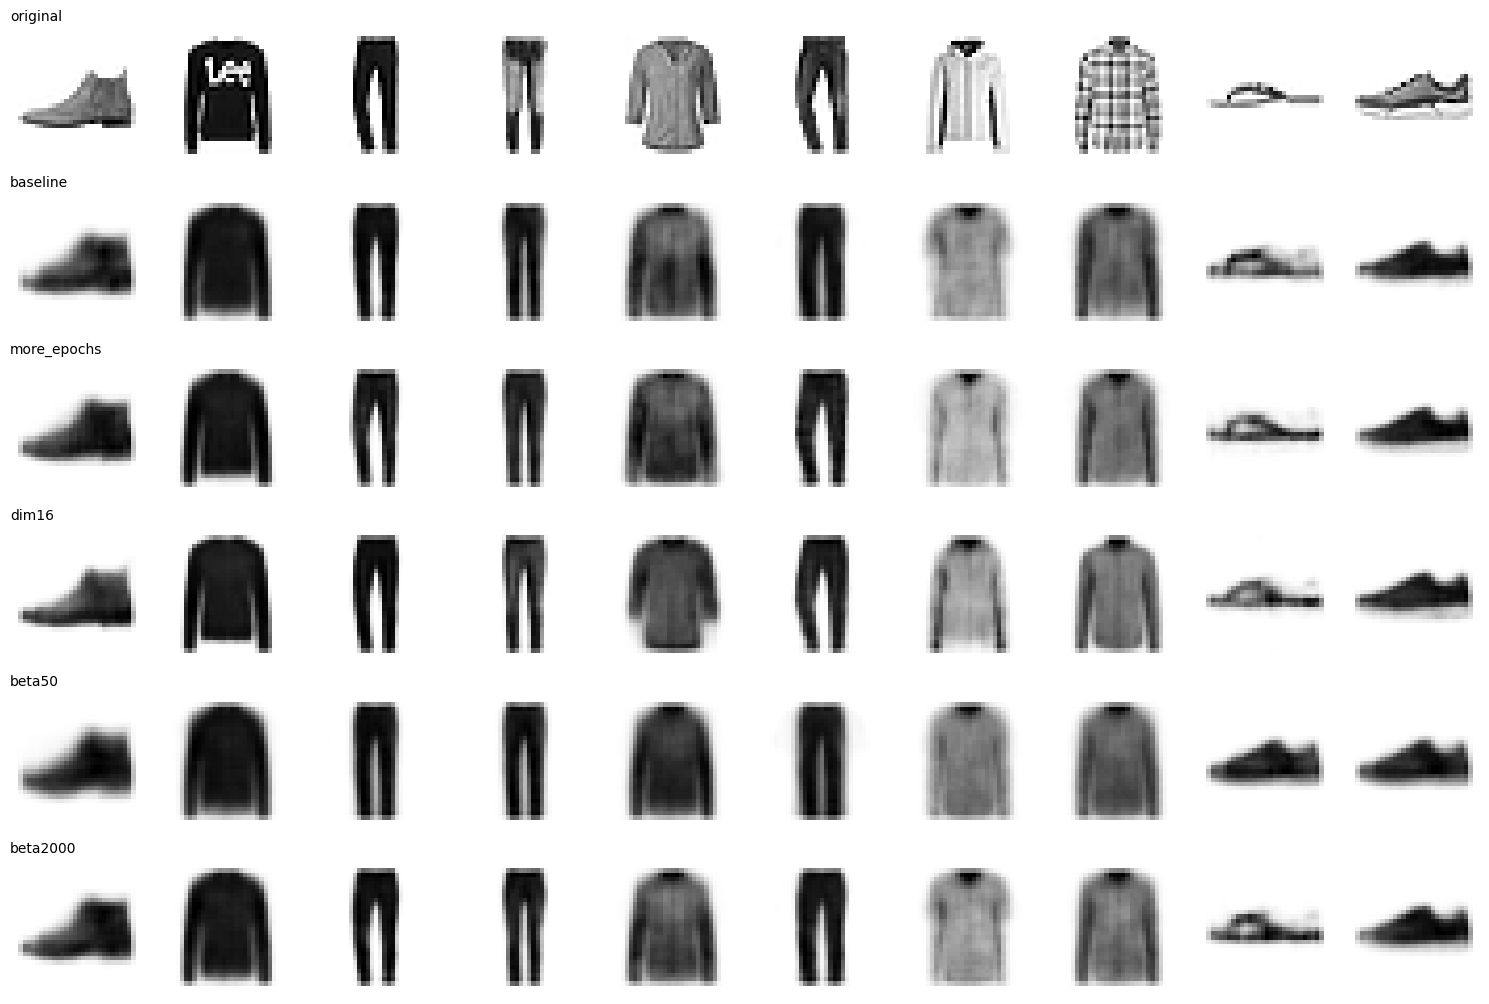

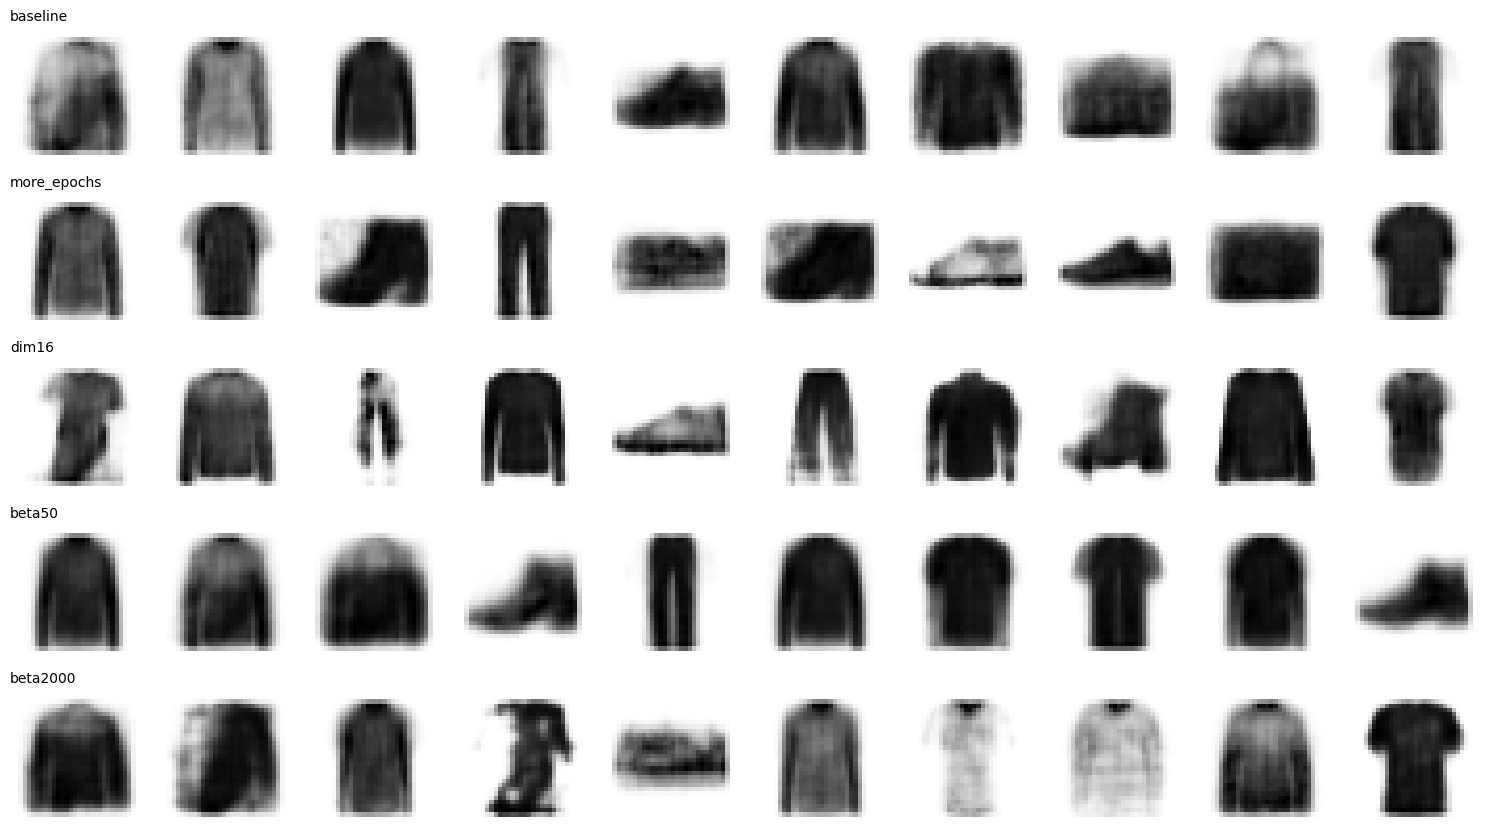

In [42]:

# observation
# No configuration preserved fine detail, for example,  the "Lee" logo, the plaid pattern, the jeans texture and the jacket stripes were lost
# in every experiment run.  The Embedding_Dim 16 value dim16. Reconstructions were the sharpest, keeping collar and sleeve edges on the shirt,
# the zipper line on the jacket, and the bent legs of the trousersers.
# more_epochs. Reconstructions were slightly sharper than baseline, and its random samples were the most varied and cleanest of all runs,
# beta50. Reconstructions were the blurriest, and the sandal was reconstructed as a solid sneaker, showing that the weaker reconstruction
# weight lost class-defining shape.KL fell to 2.15: codes hug the prior, giving plausible samples but blurry reconstructions
# beta2000. Reconstructions were visually indistinguishable from baseline, matching the identical pixel MSE.
# KL rose to 6.93: codes drift from the prior, giving samples with artefacts, yet reconstruction didn't improve.
# The two terms want opposite things from the latent space; The ELBO trade-off made visible, i.e the balance between the two ELBO terms.

def compare_images(trained, generate=False, n=10, seed=0):
    rows = len(trained) + (0 if generate else 1)
    fig, axes = plt.subplots(rows, n, figsize=(n * 1.5, rows * 1.7))
    r0 = 0
    if not generate:
        for j in range(n):
            axes[0, j].imshow(x_test[j].squeeze(), cmap="gray_r")
            axes[0, j].axis("off")
        axes[0, 0].set_title("original", loc="left", fontsize=10)
        r0 = 1
    for i, (name, (enc, dec, dim)) in enumerate(trained.items(), r0):
        if generate:
            z = np.random.default_rng(seed).normal(size=(n, dim))
        else:
            z = enc.predict(x_test[:n], verbose=0)[0]
        imgs = dec.predict(z, verbose=0)
        for j in range(n):
            axes[i, j].imshow(imgs[j].squeeze(), cmap="gray_r")
            axes[i, j].axis("off")
        axes[i, 0].set_title(name, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

compare_images(trained)                  # reconstructions of the same 10 test images
compare_images(trained, generate=True)   # new images from random N(0, I) points
#  just shouwing the trained images provided generate value true ;  # grid 2 images

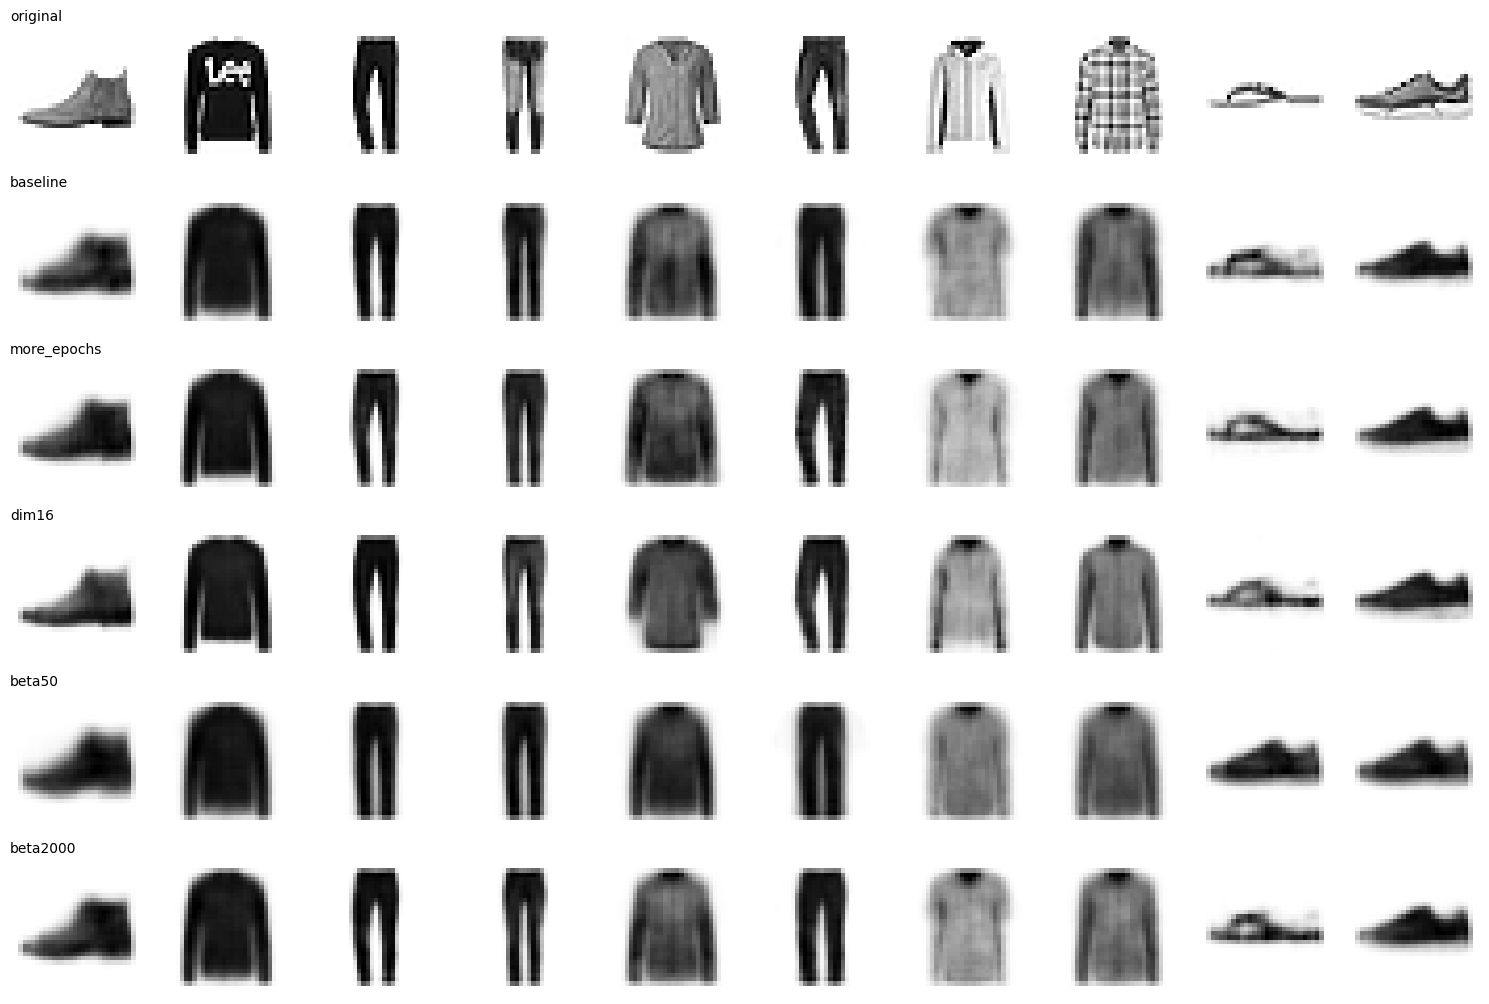

In [43]:
# just shouwing the trained images # grid 1 images
# Reconstruction (grid 1): take a real test image, encode it, decode the encoder's own z_mean, and compare with the original. The decoder is fed points the encoder chose.
compare_images(trained)